## Import libs

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## read the data

In [6]:
df = pd.read_csv("./dataset/hatevsoffensive_language.csv")
df.head(5)

,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [7]:
df_text = df[['text']]
df_text.head(5)

,text
0,!!! RT @mayasolovely: As a woman you shouldn't...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


## Text Preprocessing

### Helper functions: `remove_urls`, `remove_emoji`, `remove_unwanted_characters`

In [8]:
# preprocess the text
import re

# remove urls
def remove_urls(text):
    """
    This function will try to remove URL present in out dataset and replace it with space using regex library.

    Input Args:
        text: strings of text that may contain URLs.

    Output Args:
        text: URLs replaces with text
    """
    url_pattern = re.compile(r'http[s]?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_emoji(string):
  """
  This function will replace the emoji in string with whitespace
  """
  emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r' ', string)

def removeunwanted_characters(document):
    document = re.sub('@[A-Za-z0-9_]+', " ", document) #mentions
    document = re.sub('#[A-Za-z0-9_]+', " ", document) #hashtags 
    document = re.sub('[^A-Za-z0-9]+', " ", document)  #punctuations
    document = remove_emoji(document)     # emojis
    document = document.replace(" ", " ") # double spaces
    return document.strip()

text_removed_unwanted = df['text'].apply(removeunwanted_characters)
text_removed_unwanted.head(4)

0    RT As a woman you shouldn t complain about cle...
1    RT boy dats cold tyga dwn bad for cuffin dat h...
2    RT Dawg RT You ever fuck a bitch and she start...
3                            RT she look like a tranny
Name: text, dtype: str

### Helper functions: `remove_punct` and tokenize

In [9]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk import word_tokenize

from nltk.tokenize import RegexpTokenizer

def remove_punct(text):
    """
     This function removes the punctutations present in our text data.

     Input Args:
         text: text data.

     Returns:
         text: cleaned text.
    """
    tokenizer = RegexpTokenizer(r"\w+")
    lst = tokenizer.tokenize(" ".join(text))
    return lst

remove_punct("He did not try to navigate: after the!!!! first bold flight, for,,,,, the reaction!!!!had taken??????? something out of his soul.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['H',
 'e',
 'd',
 'i',
 'd',
 'n',
 'o',
 't',
 't',
 'r',
 'y',
 't',
 'o',
 'n',
 'a',
 'v',
 'i',
 'g',
 'a',
 't',
 'e',
 'a',
 'f',
 't',
 'e',
 'r',
 't',
 'h',
 'e',
 'f',
 'i',
 'r',
 's',
 't',
 'b',
 'o',
 'l',
 'd',
 'f',
 'l',
 'i',
 'g',
 'h',
 't',
 'f',
 'o',
 'r',
 't',
 'h',
 'e',
 'r',
 'e',
 'a',
 'c',
 't',
 'i',
 'o',
 'n',
 'h',
 'a',
 'd',
 't',
 'a',
 'k',
 'e',
 'n',
 's',
 'o',
 'm',
 'e',
 't',
 'h',
 'i',
 'n',
 'g',
 'o',
 'u',
 't',
 'o',
 'f',
 'h',
 'i',
 's',
 's',
 'o',
 'u',
 'l']

### remove stopwords

In [10]:
nltk.download("stopwords")
from  nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# get the stopwords
stop_words = set(stopwords.words("english"))

# add custom stopwords
custom_stopwords = ['@', 'RT', 'u', 'i', 'co']
stop_words.update(custom_stopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
def remove_stopwords(text_tokens):
    """
     This function removes all the stopwords present in out text tokens.
     
     Input Args:
         text_tokens: tokenize input of our datasets.
     Returns:
         result_tokens: list of token without stopword.
    """
    result_tokens = []
    for token in text_tokens:
        if token not in stop_words:
            result_tokens.append(token)
    return result_tokens

remove_stopwords(['He', 'did', 'not', 'try', 'to', 'navigate', 'after', 'the', 'first', 'bold', 'flight', ',', 'for', 'the', 'reaction', 'had', 'taken', 'something', 'out', 'of', 'his', 'soul', '.'])

['He',
 'try',
 'navigate',
 'first',
 'bold',
 'flight',
 ',',
 'reaction',
 'taken',
 'something',
 'soul',
 '.']

In [12]:
from nltk.stem import WordNetLemmatizer
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')

def lemmatization(token_text):
    """
    This function performs the lemmatization operations as explained above.

    Input Args:
        token_text: list of tokens.

    Returns:
        lemmatized_tokens: list of lemmatized tokens.
    """
    wordnet = WordNetLemmatizer()
    lemmatized_tokens = [wordnet.lemmatize(token.lower(), pos = 'v') for token in token_text]
    return lemmatized_tokens

lemmatization("Should we go walking or swimming".split())


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['should', 'we', 'go', 'walk', 'or', 'swim']

In [13]:
from nltk.stem import PorterStemmer

def stemming(text):
  """
    This function performs stemming operations.

    Input Args:
        token_text: list of tokenize text.

    Returns:
        stemm_tokes: list of stemmed tokens.
    """
  porter = PorterStemmer()
  stemm_tokens = [porter.stem(token) for token in text]
  return stemm_tokens

# test
stemming(['Connects','Connecting','Connections','Connected','Connection','Connectings','Connect'])

['connect', 'connect', 'connect', 'connect', 'connect', 'connect', 'connect']

In [14]:
def lower_order(text):
    """
    This function converts all the text in input text to lower order.

    Input Args:
        token_text : input text.

    Returns:
        small_order_text : text converted to small/lower order.
    """
    return  text.lower()

lower_order("This Is some Normalized TEXT")

'this is some normalized text'

In [15]:
def remove_contradictions(text):
    """
    This function replaces the contractions in text with their expanded form.

    Input Args:
        text: input text.

    Returns:
        expanded_text: text with contractions replaced by their expanded form.
    """
    contractions_dict = {
        "can't": "cannot",
        "won't": "will not",
        "n't": " not",
        "'re": " are",
        "'s": " is",
        "'d": " would",
        "'ll": " will",
        "'t": " not",
        "'ve": " have",
        "'m": " am",
        "aint": "am not",
        "arent": "are not",
        "cant": "cannot",
    }
    contractions_re = re.compile('(%s)' % '|'.join(contractions_dict.keys()))

    def expand_contractions(s, contractions_dict=contractions_dict):
        def replace(match):
            return contractions_dict[match.group(0)]
        return contractions_re.sub(replace, s)

    expanded_text = expand_contractions(text)
    return expanded_text
  
remove_contradictions("I can't go to the party because I won't have time.")

'I cannot go to the party because I will not have time.'

In [16]:
def text_cleaning_pipeline(dataset, rule = "lemmatize"):
  """
  This function cleans up the text, changes order, remove url, emojis and unwanted characters
  turns them to token and then lemmatize or stemm them according to the rule passed

  Input Args:
    dataset: the data col to perform these operations on
    rule: Whether to lemmatize or stemm it (Default is lemmatize)

  Output:
    cleaned list of tokens
  """
  # Convert the input to small/lower order.
  data = lower_order(dataset)
  # Remove URLs
  data = remove_urls(dataset)
  # Remove emojis
  data = remove_emoji(dataset)
  # Remove contractions
  data = remove_contradictions(dataset)
  # Remove all other unwanted characters.
  data = removeunwanted_characters(dataset)
  # Create tokens.
  tokens = data.split()

  # Remove stopwords
  tokens = remove_stopwords(tokens)
  # Remove punctuations
  tokens = remove_punct(tokens)

  if rule == "lemmatize":
    tokens = lemmatization(tokens)
  elif rule == "stem":
    tokens = stemming(tokens)
  else:
    print("Pick between lemmatize or stem")

  return " ".join(tokens)

# test
text_cleaning_pipeline( "Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? LMK when you're free cuz I can't go this or next weekend since I'll be swimming!!! #sushiBros #rawFish #🍱")

'hello i still want us hit new sushi spot lmk free cuz i go next weekend since i swim'

In [17]:
# apply on real data
df["cleaned"] = df['text'].apply(lambda data: text_cleaning_pipeline(data))
df["cleaned"].head(4)

0    as woman complain clean house amp man always t...
1    boy dats cold tyga dwn bad cuffin dat hoe 1st ...
2    dawg you ever fuck bitch start cry you confuse...
3                                     look like tranny
Name: cleaned, dtype: str

In [18]:
print(df.columns)
print(type(df["cleaned"].iloc[0]))  # should be str, not list

Index(['label', 'text', 'cleaned'], dtype='str')
<class 'str'>


## Visualization

In [19]:
from collections import Counter

all_words = " ".join(df['cleaned']).split()

common_words = Counter(all_words).most_common(20)
print(common_words)

[('bitch', 11454), ('i', 8791), ('hoe', 4346), ('get', 3081), ('http', 2915), ('like', 2862), ('fuck', 2266), ('pussy', 2148), ('ass', 1575), ('shit', 1312), ('go', 1278), ('nigga', 1227), ('trash', 1161), ('lol', 1102), ('say', 1069), ('you', 1002), ('know', 950), ('amp', 930), ('make', 911), ('niggas', 789)]


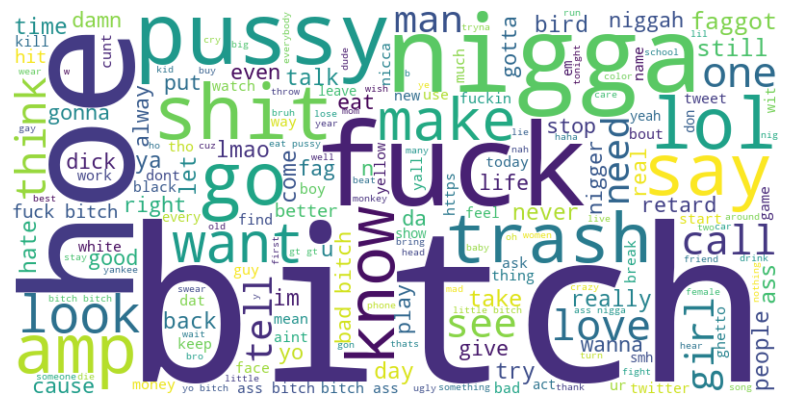

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Generate word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(df['cleaned'].str.cat(sep=' '))

# Display
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## Train test split

In [21]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['cleaned'],
                                                    df['label'],
                                                    test_size=0.2,
                                                    random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 19826
Testing set size: 4957


## Tokenization and padding

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize the Tokenizer
tokenizer = Tokenizer()

# Fit the tokenizer on the training data
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# Determine the maximum sequence length based on the 95th percentile
max_length = int(np.percentile([len(seq) for seq in X_train_sequences], 95))

# Apply padding to the sequences
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length, padding='post')

print(f"Vocabulary size: {len(tokenizer.word_index) + 1}")
print(f"Maximum sequence length: {max_length}")

Vocabulary size: 16843
Maximum sequence length: 16


## Encode the labels

In [23]:
# encode the labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Encoded labels:", np.unique(y_train_encoded))
print(label_encoder.classes_)

Encoded labels: [0 1 2]
['hate speec' 'neither' 'offensive language']


### Define Common Callbacks for models

In [32]:
# callbacks 
from tensorflow import keras
import os

os.makedirs('./model_checkpoints', exist_ok=True)

callbacks = lambda model_name: [
    keras.callbacks.ModelCheckpoint(
        filepath=f'./model_checkpoints/{model_name}',
        save_best_only=True,
        monitor='val_loss'
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4
    )
]

## Build Sequential RNN, with trainable Embedding layer

In [29]:
# 1. Simple RNN with a trainable Embedding layer.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Input

# Model 1: Simple RNN with trainable Embedding layer
model1 = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=100
    ),

    SimpleRNN(64),

    Dense(3, activation='softmax') # number of classes is 3, so we use softmax activation
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 16, 100)        │     1,684,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        10,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,695,055 (6.47 MB)

 Trainable params: 1,695,055 (6.47 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Train the model
history1 = model1.fit(
    X_train_padded,
    y_train_encoded,
    epochs=30,
    callbacks=callbacks("simple_rnn.keras"),
    batch_size=32,
    validation_data=(X_test_padded, y_test_encoded)
)

Epoch 1/30


I0000 00:00:1778208403.104803    2373 service.cc:153] XLA service 0x7f0d10030c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778208403.104827    2373 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1778208403.168116    2373 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778208403.328070    2373 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1778208403.354198    2373 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_simple_rnn_1_1_while_body_1455_grad_1610_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778208403.354283    2373 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2094__.24
I0000 00:00:1778208403.707263    2373 dot_search_space.cc:240] All config

 38/620 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7385 - loss: 0.7450

I0000 00:00:1778208405.725543    2373 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


616/620 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8441 - loss: 0.4588

I0000 00:00:1778208409.151684    2373 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_simple_rnn_1_1_while_body_1455_grad_1610_const_0__.21.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778208409.151780    2373 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2094__.24
I0000 00:00:1778208409.328769    2373 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778208409.672882    3525 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_29', 12 bytes spill stores, 12 bytes spill loads



620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8442 - loss: 0.4583

I0000 00:00:1778208412.178170    2373 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1778208412.547198    3665 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_10', 12 bytes spill stores, 12 bytes spill loads



620/620 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8707 - loss: 0.3853 - val_accuracy: 0.8947 - val_loss: 0.3044
Epoch 2/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9381 - loss: 0.1957 - val_accuracy: 0.8830 - val_loss: 0.3488
Epoch 3/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9685 - loss: 0.1002 - val_accuracy: 0.8739 - val_loss: 0.4067
Epoch 4/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9821 - loss: 0.0572 - val_accuracy: 0.8638 - val_loss: 0.4835
Epoch 5/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9879 - loss: 0.0390 - val_accuracy: 0.8689 - val_loss: 0.5093


## Build LSTM model with trainable Embedding layer

In [34]:
# LSTM with a trainable Embedding layer.
from tensorflow.keras.layers import LSTM

model2 = Sequential([
    Input(shape=(max_length,)),
    
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=100
    ),
    
    LSTM(64),
    Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 16, 100)        │     1,684,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,726,735 (6.59 MB)

 Trainable params: 1,726,735 (6.59 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history2 = model2.fit(
    X_train_padded,
    y_train_encoded,
    epochs=30,
    batch_size=32,
    callbacks=callbacks("simple_lstm.keras"),
    validation_data=(X_test_padded, y_test_encoded)
)

Epoch 1/30


620/620 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8642 - loss: 0.3854 - val_accuracy: 0.9003 - val_loss: 0.2923
Epoch 2/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9219 - loss: 0.2260 - val_accuracy: 0.8953 - val_loss: 0.2907
Epoch 3/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9453 - loss: 0.1581 - val_accuracy: 0.8921 - val_loss: 0.3218
Epoch 4/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9604 - loss: 0.1145 - val_accuracy: 0.8848 - val_loss: 0.3943
Epoch 5/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9701 - loss: 0.0861 - val_accuracy: 0.8788 - val_loss: 0.5030
Epoch 6/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9769 - loss: 0.0648 - val_accuracy: 0.8771 - val_loss: 0.5358


## Build LSTM with pretrained Word2Vec embeddings.

### Load pretrained vectors

In [36]:
# LSTM with pretrained Word2Vec embeddings.
import gensim.downloader as api

word2vec = api.load("word2vec-google-news-300")

### Build embedding matrix

In [37]:
embedding_dim = 300 # dimension of the word vectors 

embedding_matrix = np.zeros(
    (len(tokenizer.word_index) + 1, embedding_dim)
) # initialize the embedding matrix with zeros

for word, i in tokenizer.word_index.items():
    if word in word2vec:
        embedding_matrix[i] = word2vec[word] # fill the embedding matrix with the pretrained word vectors

In [38]:
# build LSTM model with pretrained embeddings
model3 = Sequential([
    Input(shape=(max_length,)),

    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False # freeze the embedding layer
    ),

    LSTM(64),
    Dense(3, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

model3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 16, 300)        │     5,052,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,146,535 (19.63 MB)

 Trainable params: 93,635 (365.76 KB)

 Non-trainable params: 5,052,900 (19.28 MB)

In [39]:
history3 = model3.fit(
    X_train_padded,
    y_train_encoded,
    epochs=30,
    batch_size=32,
    callbacks=callbacks("lstm_pretrained.keras"),
    validation_data=(X_test_padded, y_test_encoded)
)

Epoch 1/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8702 - loss: 0.3680 - val_accuracy: 0.8856 - val_loss: 0.3096
Epoch 2/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8921 - loss: 0.2902 - val_accuracy: 0.8834 - val_loss: 0.3025
Epoch 3/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8988 - loss: 0.2710 - val_accuracy: 0.8939 - val_loss: 0.2901
Epoch 4/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9031 - loss: 0.2580 - val_accuracy: 0.8917 - val_loss: 0.2915
Epoch 5/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9090 - loss: 0.2434 - val_accuracy: 0.8913 - val_loss: 0.3049
Epoch 6/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9135 - loss: 0.2313 - val_accuracy: 0.8957 - val_loss: 0.2928
Epoch 7/30
620/620 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9173 - loss: 0.2203 - val_accuracy: 0.8975 - val_loss: 0.2995


### Model accuracy and loss visualization

In [40]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """
    This function plots the training and validation accuracy and loss curves for a given model history.
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy subplot
    axes[0].plot(history.history['accuracy'])
    axes[0].plot(history.history['val_accuracy'])

    axes[0].set_title(f'{model_name} Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')

    axes[0].legend(['Train', 'Validation'])

    # Loss subplot
    axes[1].plot(history.history['loss'])
    axes[1].plot(history.history['val_loss'])

    axes[1].set_title(f'{model_name} Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')

    axes[1].legend(['Train', 'Validation'])

    plt.tight_layout()

    plt.show()

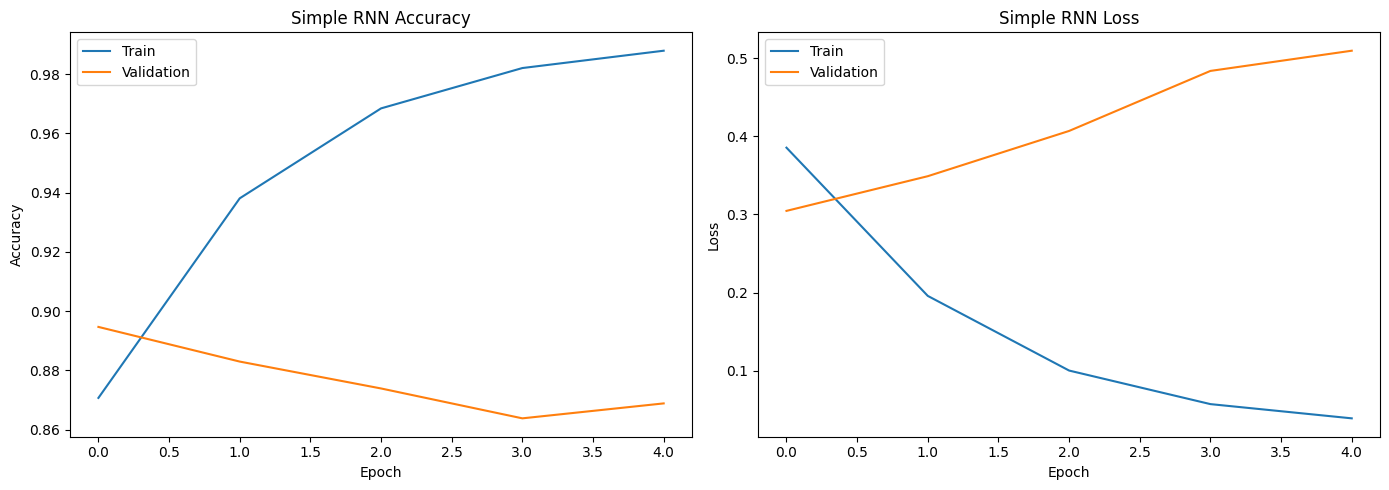

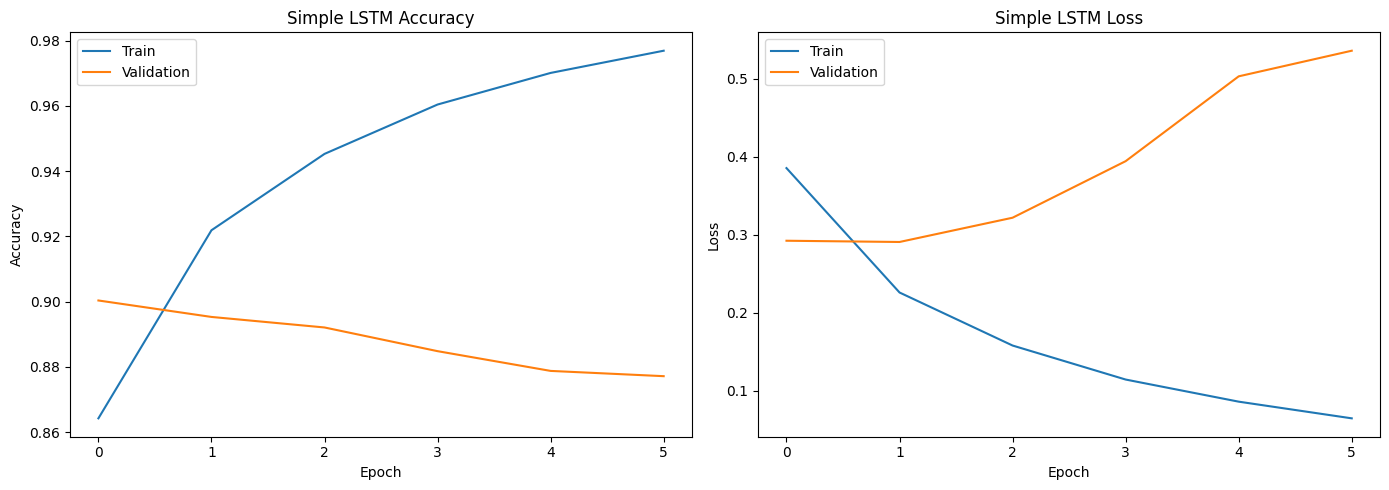

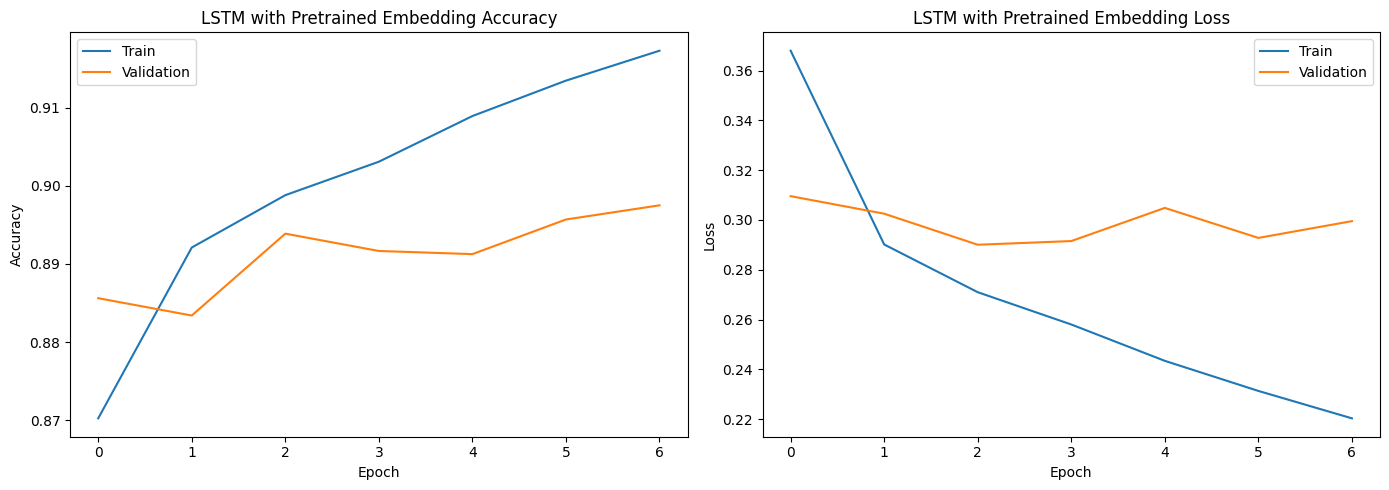

In [41]:
titles = [
    "Simple RNN",
    "Simple LSTM",
    "LSTM with Pretrained Embedding"
]

histories = [history1, history2, history3]

for i, history in enumerate(histories):
    plot_history(history, titles[i])

## Evaluation and Error analysis

In [42]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(
    model,
    X_test,
    y_test,
    encoder,
    model_name
):
    """
    Evaluate the performance of a trained model on test data.

      Input Args:
          model: The trained model to be evaluated.
          X_test: The test data features.
          y_test: The true labels for the test data.
          encoder: The label encoder used to encode the labels during training.
          model_name: A string representing the name of the model (for display purposes). 
          
      Returns:
          accuracy: The accuracy of the model on the test data.
          y_pred_classes: The predicted class labels for the test data.
    """
    # Predictions
    y_pred = model.predict(X_test)

    y_pred_classes = y_pred.argmax(axis=1)

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred_classes
    )

    print(f"\n{model_name} Accuracy: {accuracy:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(
        y_test,
        y_pred_classes
    )

    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            y_pred_classes,
            target_names=encoder.classes_
        )
    )

    return accuracy, y_pred_classes

In [43]:
# evaluate model1: Simple RNN
_, y_pred_classes_model1 = evaluate_model(
    model1,
    X_test_padded,
    y_test_encoded,
    label_encoder,
    titles[0]
)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Simple RNN Accuracy: 0.8689

Confusion Matrix:
[[  76   31  183]
 [  15  651  169]
 [ 125  127 3580]]

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.35      0.26      0.30       290
           neither       0.80      0.78      0.79       835
offensive language       0.91      0.93      0.92      3832

          accuracy                           0.87      4957
         macro avg       0.69      0.66      0.67      4957
      weighted avg       0.86      0.87      0.86      4957



In [44]:
# evaluate model2: Simple LSTM
_, y_pred_classes_model2 = evaluate_model(
    model2,
    X_test_padded,
    y_test_encoded,
    label_encoder,
    titles[1]
)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Simple LSTM Accuracy: 0.8771

Confusion Matrix:
[[  70   31  189]
 [  21  681  133]
 [  94  141 3597]]

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.38      0.24      0.29       290
           neither       0.80      0.82      0.81       835
offensive language       0.92      0.94      0.93      3832

          accuracy                           0.88      4957
         macro avg       0.70      0.67      0.68      4957
      weighted avg       0.87      0.88      0.87      4957



In [45]:
# evaluate model3: LSTM with pretrained embeddings
_, y_pred_classes_model3 = evaluate_model(
    model3,
    X_test_padded,
    y_test_encoded,
    label_encoder,
    titles[2]
)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

LSTM with Pretrained Embedding Accuracy: 0.8975

Confusion Matrix:
[[  63   42  185]
 [  17  733   85]
 [  59  120 3653]]

Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.45      0.22      0.29       290
           neither       0.82      0.88      0.85       835
offensive language       0.93      0.95      0.94      3832

          accuracy                           0.90      4957
         macro avg       0.73      0.68      0.69      4957
      weighted avg       0.88      0.90      0.89      4957



## Error Analysis and discussion

In [46]:
for i in range(len(y_pred_classes_model1)):
    if y_pred_classes_model1[i] != y_test_encoded[i]:
        print("Tweet:", X_test.iloc[i])
        print("Actual:", y_test_encoded[i])
        print("Predicted:", y_pred_classes_model1[i])
        print()

Tweet: lol credit near good i know right man job ho nice though
Actual: 1
Predicted: 2

Tweet: wipe cum faggot contact lens wildin see shit
Actual: 2
Predicted: 0

Tweet: mother ask i want christmas year reply go crazy sister bitch
Actual: 2
Predicted: 1

Tweet: search gay redneck episode 1 play
Actual: 0
Predicted: 2

Tweet: gotta love islamofascist cow try make retort age typical muzzie idiocy
Actual: 0
Predicted: 1

Tweet: jsu coach omar johnson it ball u throw hit catch doesn matter yankees
Actual: 1
Predicted: 2

Tweet: i tryna get sleep bird start get rowdy
Actual: 1
Predicted: 2

Tweet: say waste draft pick manziel mallet i tell delete account you retard
Actual: 0
Predicted: 2

Tweet: aight game dyke ruin http o0can6gb1p
Actual: 0
Predicted: 2

Tweet: see elder queer couple marry really emotional they get live final years equality dignity
Actual: 2
Predicted: 1

Tweet: kaaspiet bloempiet lol men weet van gekkigheid niet meer hoe ze simpele oplossing tegen racisme moet maken zola

## UI using gradio 

In [ ]:
import gradio as gr

def predict_tweet(text):
    cleaned = text_cleaning_pipeline(text)

    seq = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(seq, maxlen=max_length)

    pred = model2.predict(padded)

    label = label_encoder.inverse_transform(
        [pred.argmax()]
    )[0]

    return label

gr.Interface(
    fn=predict_tweet,
    inputs="text",
    outputs="text"
).launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
